In [59]:
import os
import pandas as pd
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv(r"C:\Users\Linda\Downloads\archive (2)\data.csv")

print(df.head)

<bound method NDFrame.head of       index                              title    genre  \
0         0                  Drowned Wednesday  fantasy   
1         1                      The Lost Hero  fantasy   
2         2          The Eyes of the Overworld  fantasy   
3         3                    Magic's Promise  fantasy   
4         4                     Taran Wanderer  fantasy   
...     ...                                ...      ...   
4652   4652                            Hounded  fantasy   
4653   4653  Charlie and the Chocolate Factory  fantasy   
4654   4654                         Red Rising  fantasy   
4655   4655                          Frostbite  fantasy   
4656   4656                           Radiance  fantasy   

                                                summary  
0      Drowned Wednesday is the first Trustee among ...  
1      As the book opens, Jason awakens on a school ...  
2      Cugel is easily persuaded by the merchant Fia...  
3      The book opens with He

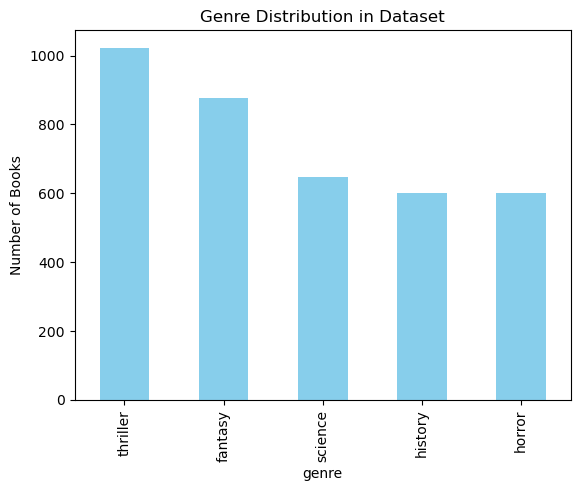

In [74]:
def preprocess(text):
    return text.lower()
common_genres = df['genre'].value_counts().nlargest(5).index
df = df[df['genre'].isin(common_genres)]

df['genre'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Genre Distribution in Dataset")
plt.ylabel("Number of Books")
plt.show()

In [61]:

vectorizer = TfidfVectorizer(max_features=5000)

df['text'] = df['title'] + " " + df['summary']


In [62]:

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['genre'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),  # unigrams + bigrams
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [63]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7053333333333334
              precision    recall  f1-score   support

     fantasy       0.77      0.79      0.78       198
     history       0.89      0.59      0.71       110
      horror       0.87      0.32      0.46       130
     science       0.78      0.75      0.77       116
    thriller       0.57      0.92      0.70       196

    accuracy                           0.71       750
   macro avg       0.78      0.67      0.68       750
weighted avg       0.75      0.71      0.69       750



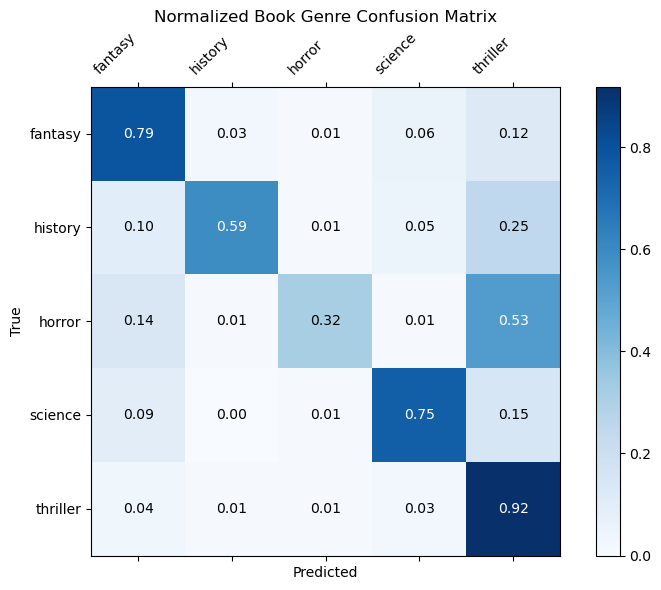

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8,6))
cax = ax.matshow(cm_normalized, cmap=plt.cm.Blues)

# Color bar
fig.colorbar(cax)

# Axis labels
ax.set_xticks(np.arange(len(model.classes_)))
ax.set_yticks(np.arange(len(model.classes_)))
ax.set_xticklabels(model.classes_, rotation=45, ha='right')
ax.set_yticklabels(model.classes_)

# Add numbers with dynamic color
threshold = cm_normalized.max() / 2.0  # If cell > 0.5 of max, use white text
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        color = "white" if cm_normalized[i, j] > threshold else "black"
        ax.text(j, i, f"{cm_normalized[i, j]:.2f}", ha='center', va='center',
                color=color)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Book Genre Confusion Matrix")
plt.tight_layout()
plt.show()

In [75]:
from wordcloud import WordCloud

text = " ".join(df[df['genre']=='fantasy']['summary_short'])
wc = WordCloud(width=400, height=200).generate(text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

ModuleNotFoundError: No module named 'wordcloud'